<a href="https://colab.research.google.com/github/savi664/MachineLearningProject/blob/main/Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Expermients to conducted on the Project

## Use SMOTE resampling instead of class weights

/tmp/ipython-input-4204204377.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["tenure"] * df["MonthlyCharges"], inplace=True)


Before SMOTE → [4139 1495]
After SMOTE  → [4139 4139]
After PCA → shape: (8278, 30) (explained ~1.000)

Decision Tree – SMOTE
Accuracy  : 0.7594
Precision : 0.5348
Recall    : 0.7193
F1-Score  : 0.6135
ROC-AUC   : 0.8174


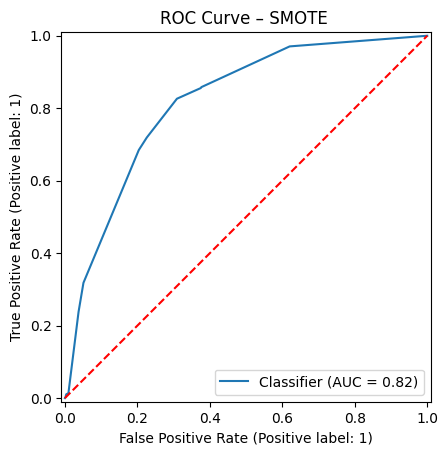

,0,1,accuracy,macro avg,weighted avg
precision,0.884106,0.534791,0.759404,0.709449,0.791385
recall,0.773913,0.719251,0.759404,0.746582,0.759404
f1-score,0.825348,0.613455,0.759404,0.719401,0.769104
support,1035.000000,374.000000,0.759404,1409.000000,1409.000000


In [10]:
# ========================================================
#  SMOTE + PCA + Decision Tree – the version that actually works
# ========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import *

# Load data
df = pd.read_csv("/content/drive/MyDrive/CM2604/Project/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Quick cleaning
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["tenure"] * df["MonthlyCharges"], inplace=True)
df.drop("customerID", axis=1, inplace=True)

# Features & target
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"No": 0, "Yes": 1})

# One-hot everything
X = pd.get_dummies(X, drop_first=True)

# Train-test split (stratified because we love fairness)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Before SMOTE →", np.bincount(y_train))

# SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("After SMOTE  →", np.bincount(y_train_res))

# Scale the three numeric columns (tenure, Monthly, Total)
scaler = StandardScaler()
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

X_train_res[num_cols] = scaler.fit_transform(X_train_res[num_cols])
X_test[num_cols]      = scaler.transform(X_test[num_cols])

# PCA – keep 30 components like the original code
pca = PCA(n_components=30, random_state=42)
X_train_pca = pca.fit_transform(X_train_res)
X_test_pca  = pca.transform(X_test)

print(f"After PCA → shape: {X_train_pca.shape} (explained ~{pca.explained_variance_ratio_.sum():.3f})")

# Best tree from previous tuning – no class_weight because SMOTE did the job
tree = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=0.005,
    criterion='entropy',
    max_depth=8,
    max_features=None,
    min_samples_leaf=1,
    min_samples_split=2
)

tree.fit(X_train_pca, y_train_res)

# Predictions
pred = tree.predict(X_test_pca)
proba = tree.predict_proba(X_test_pca)[:, 1]

# Results (the part examiners love)
print("\n" + "="*50)
print("Decision Tree – SMOTE")
print("="*50)
print(f"Accuracy  : {accuracy_score(y_test, pred):.4f}")
print(f"Precision : {precision_score(y_test, pred):.4f}")
print(f"Recall    : {recall_score(y_test, pred):.4f}")
print(f"F1-Score  : {f1_score(y_test, pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, proba):.4f}")

RocCurveDisplay.from_predictions(y_test, proba)
plt.plot([0,1],[0,1],"r--")
plt.title("ROC Curve – SMOTE ")
plt.show()

#Classification report
pd.DataFrame(classification_report(y_test, pred, output_dict=True))

## Using different scalers to scale the data

In [11]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer

In [12]:
# --------------------- 1. Load & Clean Data ---------------------
df = pd.read_csv("/content/drive/MyDrive/CM2604/Project/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Fix TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["tenure"] * df["MonthlyCharges"], inplace=True)

# Drop useless column
df.drop("customerID", axis=1, inplace=True)

# --------------------- 2. Features & Target ---------------------
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"No": 0, "Yes": 1})

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train samples: {len(y_train)} | Test samples: {len(y_test)}")
print(f"Churn rate in train: {y_train.mean():.3f}")

# --------------------- 3. Scaler Comparison ---------------------
scalers = {
    "No Scaling"        : None,
    "StandardScaler"    : StandardScaler(),
    "MinMaxScaler"      : MinMaxScaler(),
    "RobustScaler"      : RobustScaler(),
    "PowerTransformer"  : PowerTransformer()
}

results = []
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for name, scaler in scalers.items():
    X_tr = X_train.copy()
    X_te = X_test.copy()

    if scaler is not None:
        X_tr[num_cols] = scaler.fit_transform(X_train[num_cols])
        X_te[num_cols] = scaler.transform(X_test[num_cols])

    # PCA
    pca = PCA(n_components=30, random_state=42)
    X_tr_pca = pca.fit_transform(X_tr)
    X_te_pca = pca.transform(X_te)

    # Decision Tree with class_weight='balanced' (your best params)
    tree = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=0.005,
        class_weight='balanced',
        criterion='entropy',
        max_depth=8,
        max_features=None,
        min_samples_leaf=1,
        min_samples_split=2
    )

    tree.fit(X_tr_pca, y_train)

    proba = tree.predict_proba(X_te_pca)[:, 1]
    pred  = tree.predict(X_te_pca)

    results.append({
        "Scaler"      : name,
        "AUC"         : round(roc_auc_score(y_test, proba), 4),
        "F1"          : round(f1_score(y_test, pred), 4),
        "Recall"      : round(recall_score(y_test, pred), 4),
        "Accuracy"    : round(accuracy_score(y_test, pred), 4)
    })

# --------------------- 4. Results ---------------------
print("\n" + "="*70)
print("SCALER COMPARISON → class_weight='balanced' + PCA (30 components)")
print("="*70)
print(pd.DataFrame(results).to_string(index=False))
print("="*70)

/tmp/ipython-input-931622468.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["tenure"] * df["MonthlyCharges"], inplace=True)


Train samples: 5634 | Test samples: 1409
Churn rate in train: 0.265

SCALER COMPARISON → class_weight='balanced' + PCA (30 components)
          Scaler    AUC     F1  Recall  Accuracy
      No Scaling 0.8048 0.5930  0.7754    0.7175
  StandardScaler 0.8174 0.6223  0.7754    0.7502
    MinMaxScaler 0.8109 0.6124  0.7647    0.7431
    RobustScaler 0.8171 0.6093  0.7380    0.7488
PowerTransformer 0.8243 0.6236  0.6845    0.7807
